# CVM -- Protocolo 1: Random Split (divisao oficial do Aariz)
## Classificação de Estágios CVM com ResNet-50 (Fine-Tuning Completo)

**Dataset:** Aariz Cephalometric Dataset (Khalid et al., 2025)
**Protocolo de avaliação:** *Random Split* -- usa a divisão **train/valid/test já fornecida
pelos autores do dataset** (não geramos essa divisão manualmente).
**Objetivo:** servir de baseline para comparação com o protocolo LOEO
(`cvm_loeo_crossval.ipynb`), sob os **mesmos hiperparâmetros e métricas**.

| Item | Valor |
|---|---|
| Arquitetura | ResNet-50 (ImageNet), fine-tuning completo |
| Épocas | 30 |
| Batch size | 16 |
| Learning rate | 1e-4 (Adam, weight_decay=1e-4) |
| Scheduler | StepLR (step=10, gamma=0.5) |
| Pré-processamento | CLAHE + normalização ImageNet |
| Augmentation | Flip horizontal (p=0.3), rotação ±5°, ColorJitter |
| Métricas | Accuracy, F1 macro/weighted, AUC-ROC macro OvR, Cohen\'s Kappa quadrático, Matriz de Confusão |


## 0. Instalação de dependências

In [14]:
!pip install -q torch torchvision scikit-learn seaborn matplotlib pandas opencv-python requests tqdm


## 1. Imports, configuração e hiperparâmetros padronizados

In [15]:
import os, json, random, math
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, auc, cohen_kappa_score
)
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm

# ── Reprodutibilidade ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# ── Hiperparâmetros PADRONIZADOS (idênticos em ambos os notebooks) ───────────
IMG_SIZE      = 224
BATCH_SIZE    = 16
EPOCHS        = 30          # padronizado: mesmo número de épocas nos dois protocolos
LR            = 1e-4
WEIGHT_DECAY  = 1e-4         # regularização L2, padronizada
LR_STEP       = 10
LR_GAMMA      = 0.5
NUM_CLASSES   = 6
CLASS_NAMES   = ['CVM-S1', 'CVM-S2', 'CVM-S3', 'CVM-S4', 'CVM-S5', 'CVM-S6']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


Dispositivo em uso: cpu
PyTorch version: 2.12.1+cpu


## 2. Download do dataset (Figshare)

In [16]:
import os
import requests
import zipfile
from tqdm.auto import tqdm as tqdm_dl

def download_aariz(extract_path="Aariz_dataset"):
    """
    Baixa o Aariz Cephalometric Dataset diretamente do Figshare
    (Khalid et al., 2025 — DOI: 10.6084/m9.figshare.27986417.v1).
    Se a pasta já existir e tiver conteúdo, pula o download.
    """
    extract_path = Path(extract_path)
    if extract_path.exists() and any(extract_path.iterdir()):
        print(f'Dataset já presente em {extract_path}, pulando download.')
        return extract_path

    article_id = "27986417"
    api_url = f"https://api.figshare.com/v2/articles/{article_id}"
    extract_path.mkdir(parents=True, exist_ok=True)
    print('Conectando à API do Figshare...')

    response = requests.get(api_url, timeout=30)
    response.raise_for_status()
    files_list = response.json().get('files', [])
    print(f'{len(files_list)} arquivo(s) encontrados. Iniciando download...')

    for file_info in files_list:
        file_name = file_info['name']
        download_url = file_info['download_url']
        target_path = extract_path / file_name

        r = requests.get(download_url, headers={'User-Agent': 'Mozilla/5.0'}, stream=True)
        r.raise_for_status()
        with open(target_path, 'wb') as f_out, tqdm_dl(
            desc=file_name, total=int(file_info.get('size', 0)),
            unit='B', unit_scale=True, unit_divisor=1024
        ) as pbar:
            for chunk in r.iter_content(chunk_size=65536):
                if chunk:
                    f_out.write(chunk)
                    pbar.update(len(chunk))

        if file_name.endswith('.zip'):
            print(f'Extraindo {file_name}...')
            with zipfile.ZipFile(target_path, 'r') as zf:
                zf.extractall(extract_path)
            target_path.unlink()

    print('Download concluído.')
    return extract_path


DATASET_ROOT_PARENT = download_aariz()

# Localiza automaticamente a subpasta que contém train/valid/test
ORIGINAL_ROOT = None
for root, dirs, _ in os.walk(DATASET_ROOT_PARENT):
    if {'train', 'valid', 'test'}.issubset(set(dirs)):
        ORIGINAL_ROOT = Path(root)
        break

assert ORIGINAL_ROOT is not None, 'Nao encontrei train/valid/test dentro do dataset baixado.'
print(f'Dataset localizado em: {ORIGINAL_ROOT}')


Dataset já presente em Aariz_dataset, pulando download.
Dataset localizado em: Aariz_dataset\Aariz


## 3. Carregamento dos splits oficiais (train/valid/test)

In [17]:
def load_split(split: str, root: Path = ORIGINAL_ROOT) -> pd.DataFrame:
    """
    Carrega imagens e rótulos CVM de um split.

    IMPORTANTE: os splits 'train', 'valid' e 'test' usados aqui NAO sao
    definidos por nos -- sao a divisao OFICIAL fornecida pelos proprios
    autores do dataset Aariz (Khalid et al., 2025), ja estratificada por
    equipamento de aquisicao para garantir representatividade em cada
    particao. Isso assegura que a comparacao com o protocolo LOEO
    (notebook separado) parta exatamente da mesma base de imagens,
    apenas reorganizada de forma diferente.
    """
    img_dir = root / split / 'Cephalograms'
    ann_dir = root / split / 'Annotations' / 'CVM Stages'

    records = []
    for json_path in sorted(ann_dir.glob('*.json')):
        with open(json_path) as f:
            data = json.load(f)
        stage = data.get('cvm_stage', {}).get('title', '').strip()
        if not stage or stage not in CLASS_NAMES:
            continue

        img_path = None
        for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
            candidate = img_dir / (json_path.stem + ext)
            if candidate.exists():
                img_path = candidate
                break
        if img_path is None:
            continue

        records.append({
            'image_path': str(img_path),
            'ceph_id':    data.get('ceph_id', json_path.stem),
            'label':      stage,
            'label_idx':  CLASS_NAMES.index(stage)
        })

    df = pd.DataFrame(records)
    print(f'[{split}] {len(df)} imagens carregadas (split oficial Aariz).')
    return df


In [18]:
df_train = load_split('train')
df_valid = load_split('valid')
df_test  = load_split('test')

print(f'\nTotal: Treino={len(df_train)} | Validacao={len(df_valid)} | Teste={len(df_test)}')


[train] 700 imagens carregadas (split oficial Aariz).
[valid] 150 imagens carregadas (split oficial Aariz).
[test] 150 imagens carregadas (split oficial Aariz).

Total: Treino=700 | Validacao=150 | Teste=150


## 4. Distribuição de classes e pesos para CrossEntropyLoss

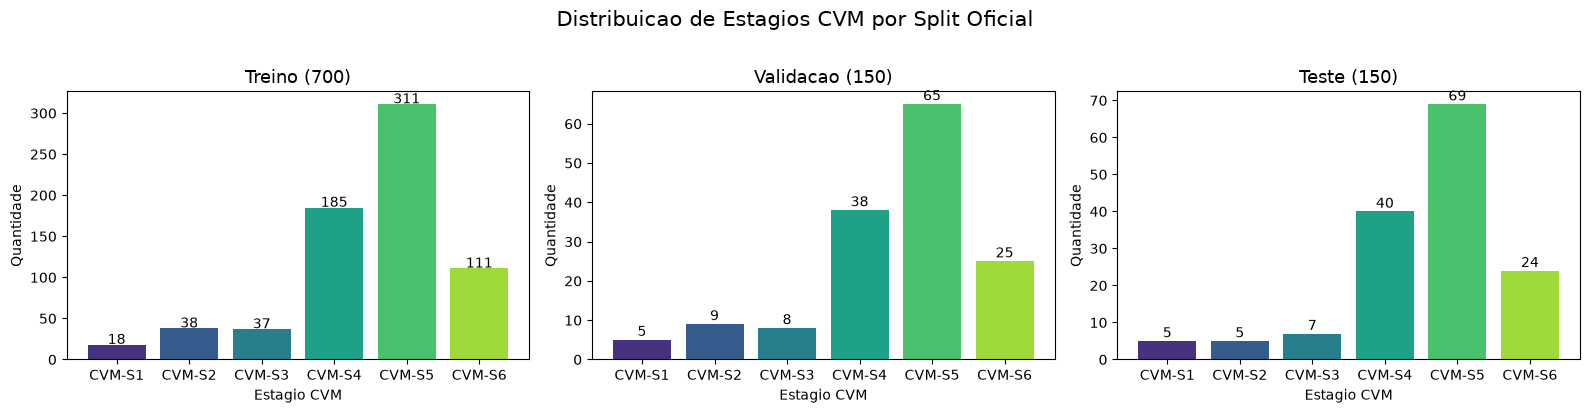

Pesos por classe (class_weight) para CrossEntropyLoss:
  CVM-S1: 2.6345
  CVM-S2: 1.2479
  CVM-S3: 1.2816
  CVM-S4: 0.2563
  CVM-S5: 0.1525
  CVM-S6: 0.4272


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = sns.color_palette('viridis', NUM_CLASSES)

for ax, (df, title) in zip(axes, [
    (df_train, f'Treino ({len(df_train)})'),
    (df_valid, f'Validacao ({len(df_valid)})'),
    (df_test,  f'Teste ({len(df_test)})')
]):
    counts = df['label'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    ax.bar(CLASS_NAMES, counts.values, color=colors)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Estagio CVM')
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('Distribuicao de Estagios CVM por Split Oficial', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('distribuicao_classes_random_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Pesos por classe (inverso da frequencia) para CrossEntropyLoss
counts_train = df_train['label'].value_counts().reindex(CLASS_NAMES, fill_value=1)
class_weights = torch.tensor(
    [1.0 / max(counts_train[c], 1) for c in CLASS_NAMES], dtype=torch.float
).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

print('Pesos por classe (class_weight) para CrossEntropyLoss:')
for name, w in zip(CLASS_NAMES, class_weights.cpu()):
    print(f'  {name}: {w:.4f}')


## 5. Dataset PyTorch (CLAHE + Augmentation)

In [20]:
def apply_clahe(img_np: np.ndarray) -> np.ndarray:
    """CLAHE no canal L do espaco LAB -- realca estruturas osseas."""
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


class CVMDataset(Dataset):
    """Dataset de classificacao CVM, com CLAHE aplicado antes das transforms."""
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row['label_idx'])
        img_bgr = cv2.imread(row['image_path'])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = apply_clahe(img_rgb)
        img_pil = Image.fromarray(img_rgb)
        if self.transform:
            img_pil = self.transform(img_pil)
        return img_pil, label


# Augmentation PADRONIZADO -- identico em ambos os notebooks
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [ ]:
train_ds = CVMDataset(df_train, transform=transform_train)
valid_ds = CVMDataset(df_valid, transform=transform_eval)
test_ds  = CVMDataset(df_test,  transform=transform_eval)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batches -> treino: {len(train_loader)} | validacao: {len(valid_loader)} | teste: {len(test_loader)}')


Batches -> treino: 44 | validacao: 10 | teste: 10


## 6. Arquitetura -- ResNet-50 com fine-tuning completo

In [22]:
def build_model(num_classes: int = NUM_CLASSES) -> nn.Module:
    """
    ResNet-50 pre-treinada na ImageNet, com FINE-TUNING COMPLETO
    (todos os parametros treinaveis -- sem congelamento de camadas).

    A camada densa final original (1000 classes) e substituida por uma
    unica camada nova, nao inicializada, com `num_classes` neuronios,
    precedida por Dropout(0.3) para regularizacao.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = True  # fine-tuning completo

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model.to(DEVICE)


In [23]:
model = build_model()

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros totais:     {total_params:,}')
print(f'Parametros treinaveis: {trainable_params:,} (fine-tuning completo)')


Parametros totais:     23,520,326
Parametros treinaveis: 23,520,326 (fine-tuning completo)


## 7. Funções de treino e avaliação padronizadas

In [24]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Executa uma epoca. Se optimizer=None, roda em modo avaliacao."""
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    running_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_training else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, desc='train' if is_training else 'eval', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if is_training:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if is_training:
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return running_loss / total, correct / total


def collect_predictions(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Predizendo'):
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_pred.extend(probs.argmax(axis=1))
            y_prob.extend(probs)
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


def evaluate_full(model, loader, present_classes=None):
    """
    Calcula o conjunto PADRONIZADO de metricas usado em AMBOS os
    notebooks (Random Split e LOEO), permitindo comparacao direta:
      - Accuracy
      - F1-Score (macro e weighted)
      - AUC-ROC macro One-vs-Rest
      - Cohen's Kappa quadratico (apropriado p/ classes ordinais como CVM)
      - Matriz de confusao (6x6, fixa, mesmo que faltem classes no fold)

    `present_classes`: indices de classe efetivamente presentes no fold.
    Necessario no LOEO, onde um equipamento pode nao conter as 6 classes.
    """
    y_true, y_pred, y_prob = collect_predictions(model, loader)

    if present_classes is None:
        present_classes = sorted(np.unique(y_true).tolist())

    acc = float((y_true == y_pred).mean())
    f1_macro = f1_score(y_true, y_pred, labels=present_classes, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, labels=present_classes, average='weighted', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    auc_macro = float('nan')
    if len(present_classes) > 1:
        try:
            y_bin = label_binarize(y_true, classes=present_classes)
            y_prob_sub = y_prob[:, present_classes]
            auc_macro = roc_auc_score(y_bin, y_prob_sub, average='macro', multi_class='ovr')
        except ValueError:
            pass  # classe unica no fold -- AUC nao definido

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    return {
        'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'auc_macro_ovr': auc_macro, 'kappa_quadratic': kappa,
        'confusion_matrix': cm, 'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob
    }


## 8. Loop de treinamento (30 épocas)

In [25]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
BEST_MODEL_PATH = 'best_cvm_model.pth'

print(f'Iniciando treinamento -- RANDOM SPLIT -- {EPOCHS} epocas\n')
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, valid_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        marker = '  <- novo melhor modelo salvo'

    print(f'Epoca {epoch:02d}/{EPOCHS} | '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}{marker}')

print(f'\nMelhor acuracia de validacao: {best_val_acc:.4f}')


Iniciando treinamento -- RANDOM SPLIT -- 30 epocas



Epoca 01/30 | train_loss=1.8183 train_acc=0.1957 | val_loss=1.8228 val_acc=0.3000  <- novo melhor modelo salvo


Epoca 02/30 | train_loss=1.5899 train_acc=0.3200 | val_loss=1.5287 val_acc=0.3467  <- novo melhor modelo salvo


Epoca 03/30 | train_loss=1.4774 train_acc=0.3243 | val_loss=1.6367 val_acc=0.3200


Epoca 04/30 | train_loss=1.2750 train_acc=0.3929 | val_loss=1.8609 val_acc=0.3867  <- novo melhor modelo salvo


...

Epoca 26/30 | train_loss=0.1207 train_acc=0.9414 | val_loss=3.1731 val_acc=0.4067


Epoca 27/30 | train_loss=0.1087 train_acc=0.9529 | val_loss=3.1024 val_acc=0.3667


Epoca 28/30 | train_loss=0.0869 train_acc=0.9600 | val_loss=3.1596 val_acc=0.4000


Epoca 29/30 | train_loss=0.0907 train_acc=0.9486 | val_loss=3.2568 val_acc=0.4400


Epoca 30/30 | train_loss=0.0891 train_acc=0.9614 | val_loss=3.2702 val_acc=0.4133

Melhor acuracia de validacao: 0.4933


## 9. Curvas de treinamento

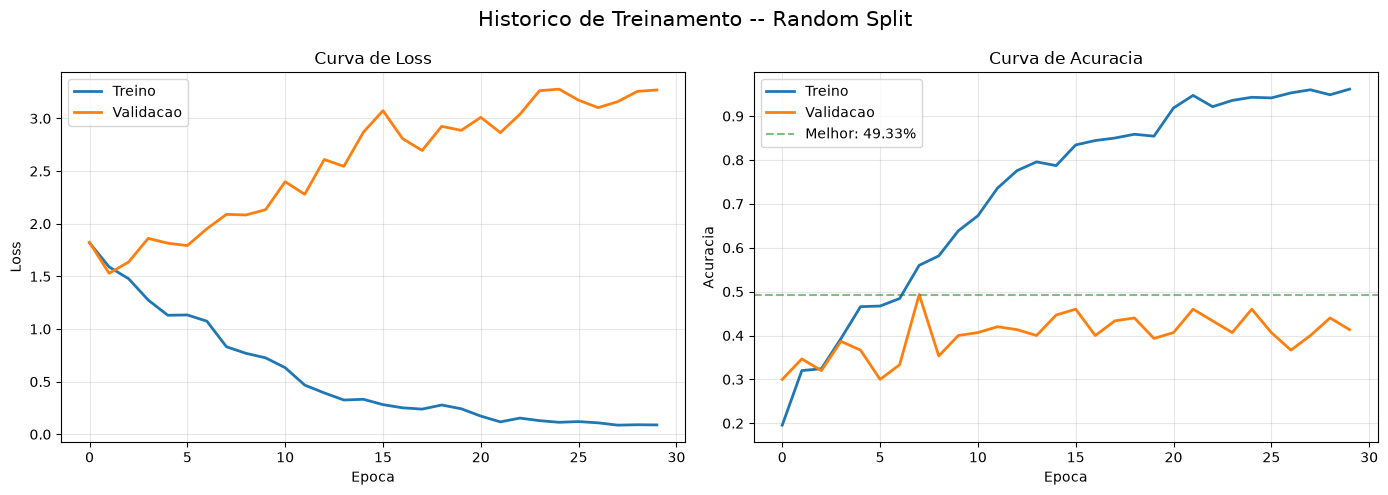

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Treino', linewidth=2)
axes[0].plot(history['val_loss'], label='Validacao', linewidth=2)
axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Treino', linewidth=2)
axes[1].plot(history['val_acc'], label='Validacao', linewidth=2)
axes[1].axhline(y=best_val_acc, color='green', linestyle='--', alpha=0.5,
                label=f'Melhor: {100*best_val_acc:.2f}%')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Acuracia')
axes[1].set_title('Curva de Acuracia'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Historico de Treinamento -- Random Split', fontsize=15)
plt.tight_layout()
plt.savefig('curvas_treinamento_random_split.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Avaliação no conjunto de teste (métricas padronizadas)

In [27]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
metrics_test = evaluate_full(model, test_loader)

print('=' * 60)
print('  METRICAS NO CONJUNTO DE TESTE -- RANDOM SPLIT (oficial Aariz)')
print('=' * 60)
print(f"  Accuracy            : {metrics_test['accuracy']:.4f}")
print(f"  F1-Score (macro)    : {metrics_test['f1_macro']:.4f}")
print(f"  F1-Score (weighted) : {metrics_test['f1_weighted']:.4f}")
print(f"  AUC-ROC (macro OvR) : {metrics_test['auc_macro_ovr']:.4f}")
print(f"  Cohen's Kappa (quad): {metrics_test['kappa_quadratic']:.4f}")
print('=' * 60)

print('\nRelatorio por classe:')
print(classification_report(metrics_test['y_true'], metrics_test['y_pred'],
                             target_names=CLASS_NAMES, digits=4, zero_division=0))


Predizendo: 100%|██████████| 10/10 [00:41<00:00,  4.14s/it]


  METRICAS NO CONJUNTO DE TESTE -- RANDOM SPLIT (oficial Aariz)
  Accuracy            : 0.5000
  F1-Score (macro)    : 0.3432
  F1-Score (weighted) : 0.4918
  AUC-ROC (macro OvR) : 0.7639
  Cohen's Kappa (quad): 0.5566

Relatorio por classe:
              precision    recall  f1-score   support

      CVM-S1     0.2857    0.4000    0.3333         5
      CVM-S2     0.0000    0.0000    0.0000         5
      CVM-S3     0.2222    0.2857    0.2500         7
      CVM-S4     0.4545    0.3750    0.4110        40
      CVM-S5     0.5974    0.6667    0.6301        69
      CVM-S6     0.4545    0.4167    0.4348        24

    accuracy                         0.5000       150
   macro avg     0.3357    0.3573    0.3432       150
weighted avg     0.4886    0.5000    0.4918       150



## 11. Matriz de confusão e curvas ROC

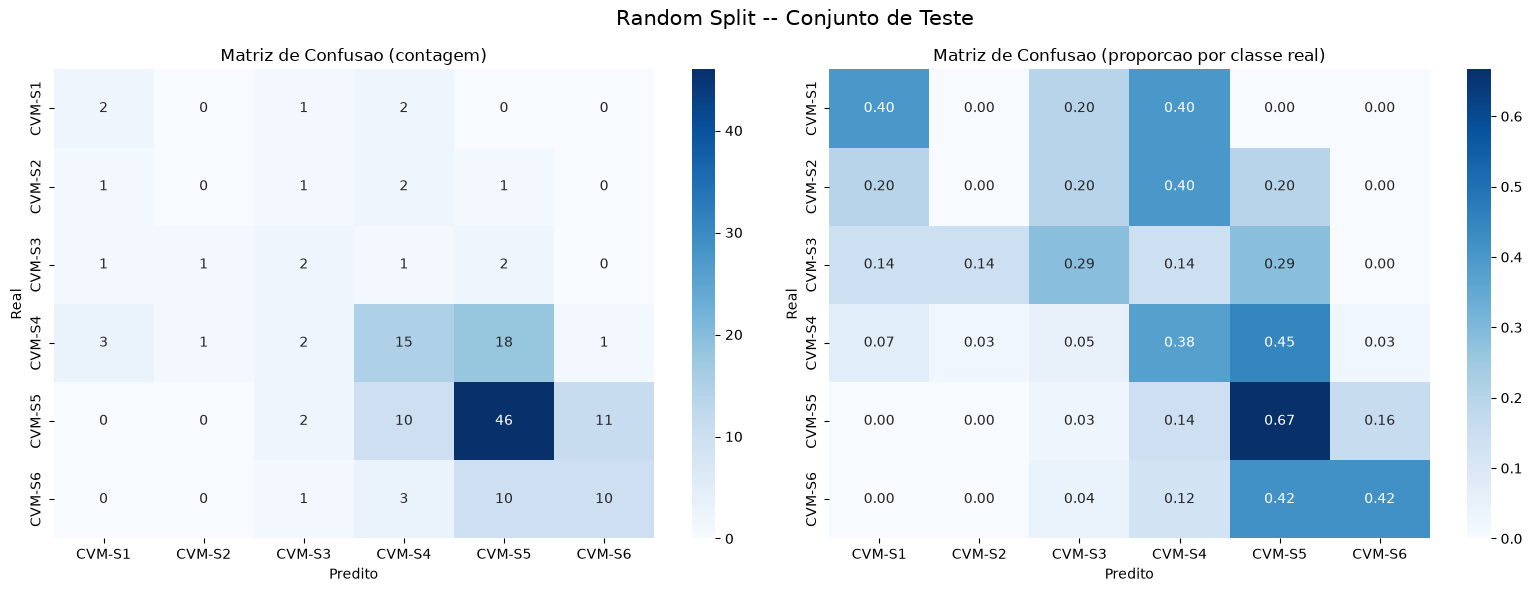

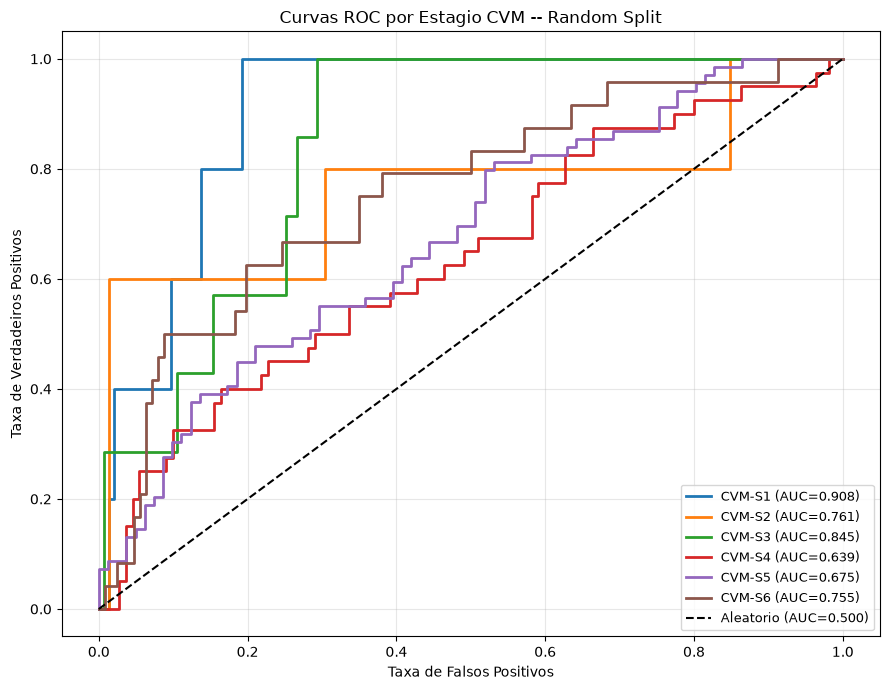

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = metrics_test['confusion_matrix']
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Matriz de Confusao (contagem)')
axes[0].set_xlabel('Predito'); axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Matriz de Confusao (proporcao por classe real)')
axes[1].set_xlabel('Predito'); axes[1].set_ylabel('Real')

plt.suptitle('Random Split -- Conjunto de Teste', fontsize=15)
plt.tight_layout()
plt.savefig('matriz_confusao_random_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Curvas ROC por classe (One-vs-Rest)
y_bin_full = label_binarize(metrics_test['y_true'], classes=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = sns.color_palette('tab10', NUM_CLASSES)
for i, (cname, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin_full[:, i], metrics_test['y_prob'][:, i])
    roc_auc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cname} (AUC={roc_auc_i:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatorio (AUC=0.500)')
ax.set_xlabel('Taxa de Falsos Positivos'); ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curvas ROC por Estagio CVM -- Random Split')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_roc_random_split.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. (Informativo) Acurácia por equipamento no split oficial

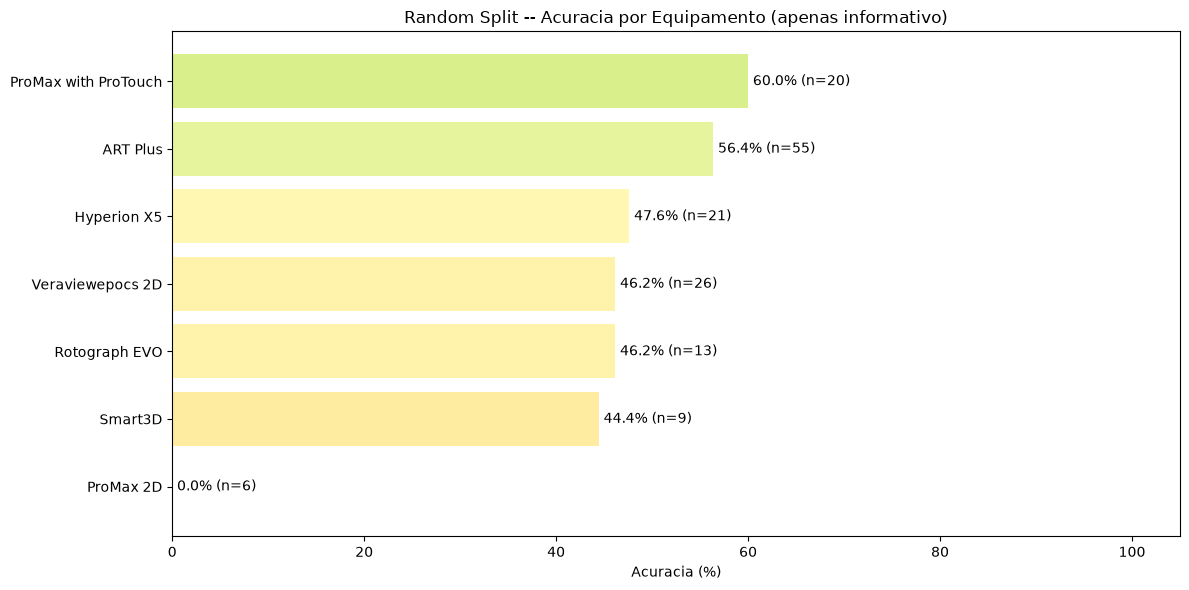

             machine  accuracy  count
            ART Plus 56.363636     55
         Hyperion X5 47.619048     21
           ProMax 2D  0.000000      6
ProMax with ProTouch 60.000000     20
       Rotograph EVO 46.153846     13
             Smart3D 44.444444      9
    Veraviewepocs 2D 46.153846     26


In [29]:
machine_csv = ORIGINAL_ROOT / 'cephalogram_machine_mappings.csv'
if machine_csv.exists():
    machines_df = pd.read_csv(machine_csv)
    ceph_to_machine = dict(zip(machines_df['cephalogram_id'], machines_df['machine']))

    df_test_eval = df_test.copy()
    df_test_eval['machine'] = df_test_eval['ceph_id'].map(ceph_to_machine)
    df_test_eval['pred_idx'] = metrics_test['y_pred']
    df_test_eval['correct'] = df_test_eval['label_idx'] == df_test_eval['pred_idx']
    df_test_eval = df_test_eval.dropna(subset=['machine'])

    acc_by_machine = df_test_eval.groupby('machine').agg(
        accuracy=('correct', 'mean'), count=('correct', 'count')
    ).reset_index()
    acc_by_machine['accuracy'] *= 100

    plt.figure(figsize=(12, 6))
    acc_sorted = acc_by_machine.sort_values('accuracy')
    plt.barh(acc_sorted['machine'], acc_sorted['accuracy'],
             color=[plt.cm.RdYlGn(a/100) for a in acc_sorted['accuracy']])
    plt.xlabel('Acuracia (%)'); plt.xlim(0, 105)
    plt.title('Random Split -- Acuracia por Equipamento (apenas informativo)')
    for i, (_, row) in enumerate(acc_sorted.iterrows()):
        plt.text(row['accuracy'] + 0.5, i, f"{row['accuracy']:.1f}% (n={int(row['count'])})", va='center')
    plt.tight_layout()
    plt.savefig('acuracia_por_equipamento_random_split.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(acc_by_machine.to_string(index=False))
else:
    print('cephalogram_machine_mappings.csv nao encontrado -- pulando quebra por equipamento.')


## 13. Salvar resultados

In [31]:
results_summary = pd.DataFrame([{
    'Protocolo':          'Random Split (oficial Aariz)',
    'Epocas':             EPOCHS,
    'Fine-tuning':        'Completo',
    'Accuracy':           round(metrics_test['accuracy'], 4),
    'F1_macro':           round(metrics_test['f1_macro'], 4),
    'F1_weighted':        round(metrics_test['f1_weighted'], 4),
    'AUC_ROC_macro_OvR':  round(metrics_test['auc_macro_ovr'], 4),
    'Cohen_Kappa_quad':   round(metrics_test['kappa_quadratic'], 4),
    'N_teste':            len(metrics_test['y_true']),
}])
results_summary.to_csv('resultados_random_split.csv', index=False)
print('Resultados salvos em resultados_random_split.csv')
print(results_summary.to_string(index=False))


Resultados salvos em resultados_random_split.csv
                   Protocolo  Epocas Fine-tuning  Accuracy  F1_macro  F1_weighted  AUC_ROC_macro_OvR  Cohen_Kappa_quad  N_teste
Random Split (oficial Aariz)      30    Completo       0.5    0.3432       0.4918             0.7639            0.5566      150
